# Step 1: Build a model ready dataset by combining `PubChem + ChEMBL` data

This notebook is the data preparation step of the workflow. It assembles a clean, model ready training set of bioactivity data (`Step0_GetBioactivityData.ipynb`) for the selected `target`. It combines ChEMBL and PubChem records, filters to the target, canonicalizes SMILES,
remove reference drugs and cleans the potency label. The output is a single .csv file that next notebook used to train ML models. No model is trained here.

In [2]:
import os
import warnings

warnings.filterwarnings("ignore")       


from io import BytesIO
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from PIL import Image


# Canonicalization functions
def canonicalizeSmiles(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

## Configuration

In [4]:
def findProjectRoot(startDir=None, marker="Input_Data"):
    """Walk upward until a folder containing `marker` is found."""
    current = os.path.abspath(startDir or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(current, marker)):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            raise FileNotFoundError(
                f"No project root containing '{marker}' above {os.getcwd()}")
        current = parent

projectRoot = findProjectRoot()

# Set target to any pathogen present in your data.
target      = "Ebola"
targetColumn = "Virus"

dataDir    = os.path.join(projectRoot, "Input_Data")
resultsDir = os.path.join(projectRoot, target, f"Results_{target}")
os.makedirs(resultsDir, exist_ok=True)

# Datasets to combine. Each entry names its file and its source database.
datasets = [
    {"fileName": "allVirusData_chEMBL_uM.csv", "source": "ChEMBL", "role": "chemblMaster"},
    {"fileName": "allVirus_Pubchem.csv",        "source": "PubChem", "role": "pubchemMaster"},
]

for entry in datasets:
    entry["path"]   = os.path.join(dataDir, entry["fileName"])
    entry["exists"] = os.path.exists(entry["path"])

byRole = {entry["role"]: entry for entry in datasets}
chemblMasterFile  = byRole["chemblMaster"]["path"]
pubchemMasterFile = byRole["pubchemMaster"]["path"]

ReferenceDrugs = {
    "Remdesivir":    "CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1",
    "Molnupiravir":  r"CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O",
    "Favipiravir":   "C1=C(N=C(C(=O)N1)C(=O)N)F",
    "Brincidofovir": "CCCCCCCCCCCCCCCCOCCCOP(=O)(CO[C@@H](CN1C=CC(=NC1=O)N)CO)O",
}

print("Project root  :", projectRoot)
print("Data directory:", dataDir)
print("Results dir   :", resultsDir)
print("Target        :", target)
print()
print("Datasets:")
for source in sorted({entry["source"] for entry in datasets}):
    print(f"  {source}:")
    for entry in datasets:
        if entry["source"] == source:
            status = "found" if entry["exists"] else "MISSING"
            print(f"    [{status}] {entry['path']}")

Project root  : /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera
Data directory: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Input_Data
Results dir   : /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola
Target        : Ebola

Datasets:
  ChEMBL:
    [found] /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Input_Data/allVirusData_chEMBL_uM.csv
  PubChem:
    [found] /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Input_Data/allVirus_Pubchem.csv


## Read potency data for the target from ChEMBL

The ChEMBL master already contains every strain for each target, so a single
filter on `targetColumn` selects all of the target's records.

In [3]:
chemblMaster = pd.read_csv(chemblMasterFile)

# Drop any embedding columns if present (the master is the pre-MACAW uM table).
chemblMaster = chemblMaster.drop(
    columns=[c for c in chemblMaster.columns if "macaw_" in c], errors="ignore"
)

# Keep only the selected target.
targetChemblData = chemblMaster[chemblMaster[targetColumn] == target].copy()

# Drop rows with missing potency.
potencyCols = [c for c in targetChemblData.columns if "potency" in c.lower()]
targetChemblData = targetChemblData.dropna(subset=potencyCols)

targetChemblData

,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,standard_relation,...,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,Virus,value_uM,pPotency,pPotencyMid,invalidSmiles,strain
13075,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C37H42N3O5P,BCNOLUKYPQLFDY-UHFFFAOYSA-N,"InChI=1S/C37H42N3O5P/c1-3-43-46(41,44-4-2)27-3...",639.73,Unknown,1880.0,nM,'=',...,2.0,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,1.88,5.725842,5.725842,False,NaN
13076,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C38H41F3N3O5P,YPONQFDDBHJAOJ-UHFFFAOYSA-N,"InChI=1S/C38H41F3N3O5P/c1-3-47-50(45,48-4-2)26...",707.73,Unknown,2490.0,nM,'=',...,2.0,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,2.49,5.603801,5.603801,False,NaN
13080,CHEMBL5084473,CCC(CC)COC(=O)[C@@H](C)N[P@](=O)(OC[C@H]1O[C@@...,C39H56N9O9P,MPBWXQGVIJRXSW-DTMJIXHDSA-N,InChI=1S/C39H56N9O9P/c1-4-29(5-2)24-53-38(51)2...,825.90,Unknown,830.0,nM,'=',...,3.0,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,0.83,6.080922,6.080922,False,NaN
13081,CHEMBL2323050,N#Cc1ccc(CN2CCN(C(=O)CNC(=O)CC34CC5CC(CC(C5)C3...,C26H34N4O2,WBJINYWRUWVQDS-UHFFFAOYSA-N,InChI=1S/C26H34N4O2/c27-16-19-1-3-20(4-2-19)18...,434.58,Small molecule,8000.0,nM,'=',...,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,8.00,5.096910,5.096910,False,NaN
13082,CHEMBL2323047,COc1ccc(CN2CCN(C(=O)CNC(=O)CC34CC5CC(CC(C5)C3)...,C26H37N3O3,OLEBDHFJFRHPFI-UHFFFAOYSA-N,InChI=1S/C26H37N3O3/c1-32-23-4-2-19(3-5-23)18-...,439.60,Small molecule,5400.0,nM,'=',...,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus,Ebola,5.40,5.267606,5.267606,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15604,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,nM,'=',...,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,Ebola,0.52,6.283997,6.283997,NaN,ZaireEbola
15605,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,nM,'=',...,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,Ebola,0.52,6.283997,6.283997,NaN,ZaireEbola
15606,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,nM,'=',...,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,Ebola,1.90,5.721246,5.721246,NaN,ZaireEbola
15607,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,nM,'=',...,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,Ebola,1.90,5.721246,5.721246,NaN,ZaireEbola


### Rename columns to the common schema

In [4]:
targetChemblData = targetChemblData.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
})
targetChemblData = targetChemblData.filter(
    items=["compound_id", "Smiles", "pPotency", targetColumn]
)
targetChemblData

,compound_id,Smiles,pPotency,Virus
13075,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.725842,Ebola
13076,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.603801,Ebola
13080,CHEMBL5084473,CCC(CC)COC(=O)[C@@H](C)N[P@](=O)(OC[C@H]1O[C@@...,6.080922,Ebola
13081,CHEMBL2323050,N#Cc1ccc(CN2CCN(C(=O)CNC(=O)CC34CC5CC(CC(C5)C3...,5.096910,Ebola
13082,CHEMBL2323047,COc1ccc(CN2CCN(C(=O)CNC(=O)CC34CC5CC(CC(C5)C3)...,5.267606,Ebola
...,...,...,...,...
15604,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,Ebola
15605,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,Ebola
15606,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,Ebola
15607,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,Ebola


## Read PubChem bioassay data for the target

In [5]:
targetPubchemData = pd.read_csv(pubchemMasterFile)

# Keep only records for the selected target.
targetPubchemData = targetPubchemData[targetPubchemData[targetColumn] == target]

# Drop rows with missing potency.
potencyCols = [c for c in targetPubchemData.columns if "potency" in c.lower()]
targetPubchemData = targetPubchemData.dropna(subset=potencyCols)

targetPubchemData = targetPubchemData.filter(
    items=["compound_id", "Smiles", "pPotency", targetColumn]
)
targetPubchemData

,compound_id,Smiles,pPotency,Virus
0,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216,Ebola
1,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186,Ebola
2,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850,Ebola
3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993,Ebola
4,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Ebola
...,...,...,...,...
1113,7601500,O=C(CC12CC3CC(CC(C3)C1)C2)NCC(=O)N1CCN(C(=O)c2...,5.522879,Ebola
1114,71262814,O=C(CC12CC3CC(CC(C3)C1)C2)NCC(=O)N1CCN(Cc2cccc...,5.468521,Ebola
1115,71528728,CN(CC(=O)N1CCN(Cc2ccccc2)CC1)C(=O)CC12CC3CC(CC...,5.173925,Ebola
1116,71528730,O=C(CC12CC3CC(CC(C3)C1)C2)NCC(=O)N1CCN(Cc2cccc...,5.698970,Ebola


### Combine PubChem + ChEMBL data

In [6]:
targetData_allDB = pd.concat(
    [targetPubchemData, targetChemblData],
    ignore_index=True,
)
targetData_allDB

,compound_id,Smiles,pPotency,Virus
0,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216,Ebola
1,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186,Ebola
2,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850,Ebola
3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993,Ebola
4,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Ebola
...,...,...,...,...
2777,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,Ebola
2778,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,Ebola
2779,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,Ebola
2780,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,Ebola


### Canonicalize the SMILES

In [7]:
targetData_allDB["Smiles"] = (
    targetData_allDB["Smiles"]
    .astype(str)
    .apply(canonicalizeSmiles)
)

targetData_allDB = targetData_allDB.rename(columns={"Smiles": "Canonical_SMILES"})
targetData_allDB

,compound_id,Canonical_SMILES,pPotency,Virus
0,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216,Ebola
1,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186,Ebola
2,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850,Ebola
3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993,Ebola
4,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Ebola
...,...,...,...,...
2777,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,Ebola
2778,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,Ebola
2779,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,Ebola
2780,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,Ebola


### Show structures

Saved: Results_Ebola/Ebola_fourCompounds.png


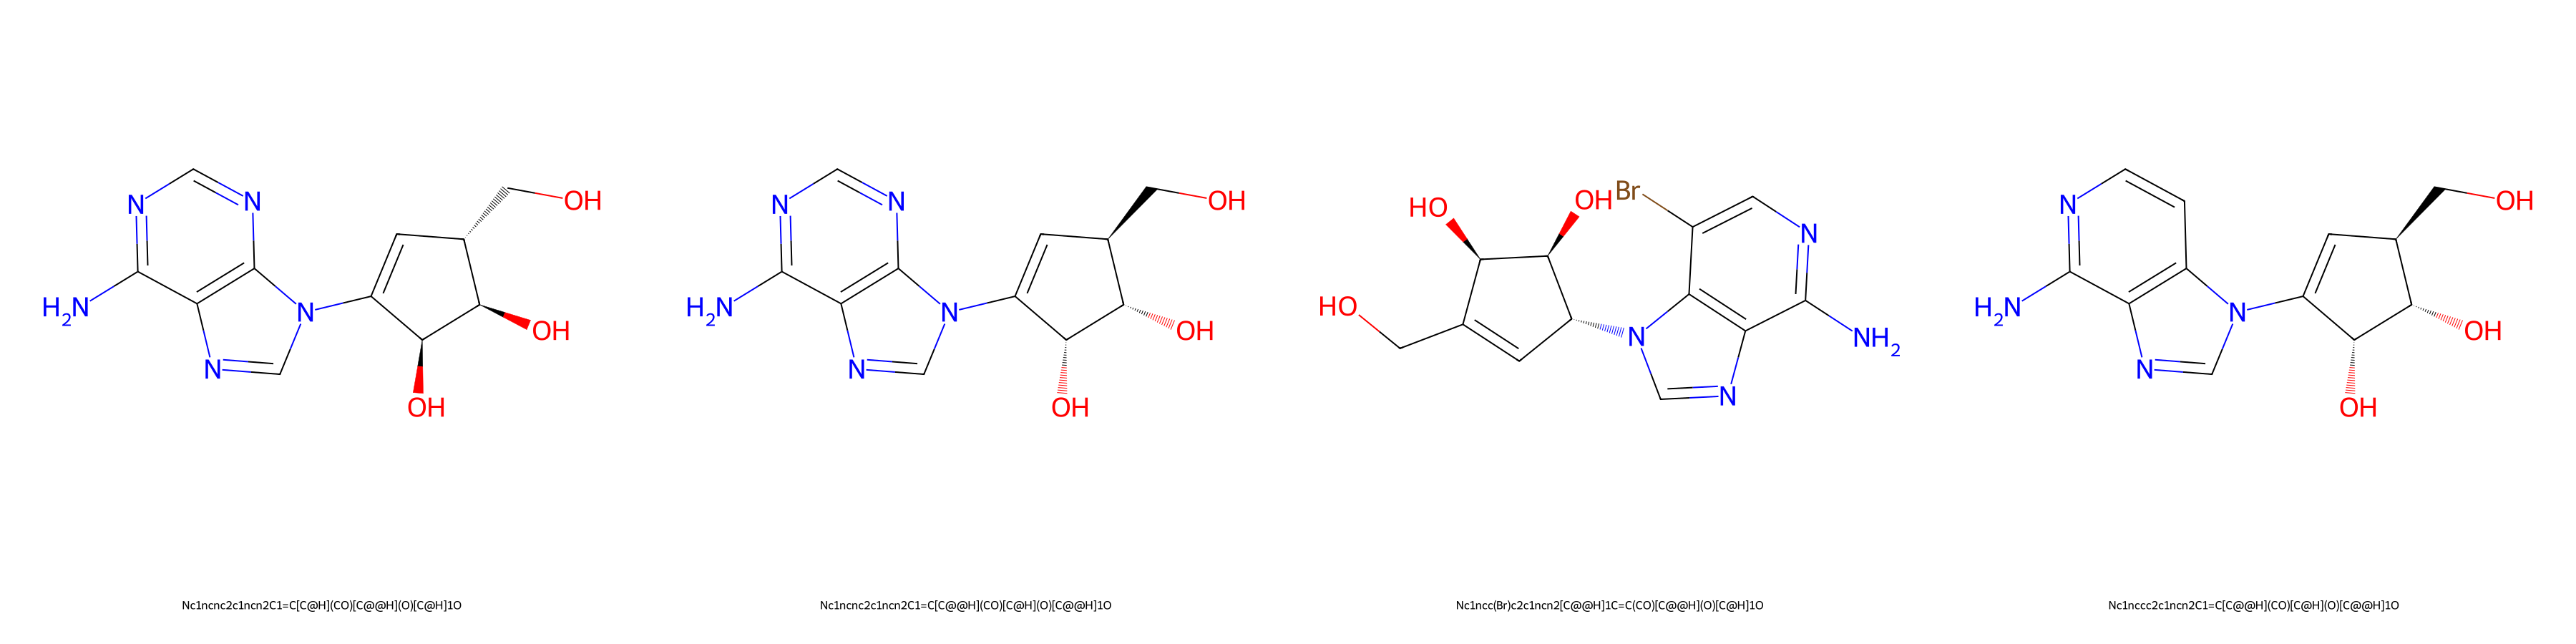

In [8]:
smilesList = targetData_allDB["Canonical_SMILES"].dropna().unique()[:4]

mols = [Chem.MolFromSmiles(str(s)) for s in smilesList]
labels = [str(s) for s in smilesList]

keep = [(m, l) for m, l in zip(mols, labels) if m is not None]
mols = [m for m, _ in keep]
labels = [l for _, l in keep]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(900, 900),      # large pixel size so 600 dpi output stays sharp
    legends=labels,
    useSVG=False,
    returnPNG=False,            # returns a PIL Image
)

# Ensure we have a PIL Image, then save at 600 dpi.
if not isinstance(img, Image.Image):
    img = Image.open(BytesIO(img.data if hasattr(img, "data") else img))

fourCompoundsPath = os.path.join(resultsDir, f"{target}_fourCompounds.png")
img.convert("RGB").save(fourCompoundsPath, format="PNG", dpi=(600, 600))
print("Saved:", fourCompoundsPath)
img

### Remove reference drugs (held out) from the training set

The reference drugs are defined in `ReferenceDrugs` in the job configuration.
They are matched on canonical SMILES and removed so they can serve as an
independent evaluation set. An empty `ReferenceDrugs` removes nothing.

In [9]:
# Canonical SMILES set for all held-out reference drugs.
referenceCanonicalSet = {
    Chem.MolToSmiles(Chem.MolFromSmiles(smi), canonical=True)
    for smi in ReferenceDrugs.values()
    if Chem.MolFromSmiles(smi) is not None
}

# Canonicalize all SMILES in the dataframe for matching.
df = targetData_allDB.copy()
df["canonical_smiles"] = df["Canonical_SMILES"].apply(
    lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s), canonical=True)
    if Chem.MolFromSmiles(s) is not None else None
)

# Remove rows whose canonical SMILES match a held-out reference drug.
dfClean = df[~df["canonical_smiles"].isin(referenceCanonicalSet)].copy()

print(f"Original shape: {len(df)}")
print(f"Removed (matches any reference drug): {len(df) - len(dfClean)}")
print(f"Remaining shape: {len(dfClean)}")

targetData_allDB = dfClean.drop(columns="canonical_smiles")
targetData_allDB

Original shape: 2782
Removed (matches any reference drug): 78
Remaining shape: 2704


,compound_id,Canonical_SMILES,pPotency,Virus
0,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216,Ebola
1,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186,Ebola
2,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850,Ebola
3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993,Ebola
4,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Ebola
...,...,...,...,...
2777,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,Ebola
2778,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,Ebola
2779,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,Ebola
2780,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,Ebola


### Plot the potency distribution in the training data

In [10]:
# Bins for non-negative values: 0-3, 3-4, ..., 11-12, >12
bins = [0] + list(range(3, 13)) + [np.inf]
labels = ["0-3"] + [f"{i}-{i+1}" for i in range(3, 12)] + ["> 12"]

df = targetData_allDB.copy()

# Coerce to numeric (invalid entries become NaN).
p = pd.to_numeric(df["pPotency"], errors="coerce")

# Build categories including NaN and negatives.
cat = pd.Series(index=df.index, dtype="object")
cat[p.isna()] = "NaN"
cat[(~p.isna()) & (p < 0)] = "<0"

# Categorize non-negative values.
cat[(~p.isna()) & (p >= 0)] = pd.cut(
    p[(~p.isna()) & (p >= 0)],
    bins=bins,
    labels=labels,
    right=False,
    ordered=True,
)

df["pPotency_category"] = cat

order = ["NaN", "<0"] + labels
categoryCounts = df["pPotency_category"].value_counts().reindex(order, fill_value=0)
total = categoryCounts.sum()
categoryPercent = (categoryCounts / total * 100).round(0).astype(int)

potencyDist = pd.DataFrame({
    "pPotency Range": categoryCounts.index.astype(str),
    "Count": categoryCounts.values,
    "Percent (%)": categoryPercent.values,
})

potencyDist

,pPotency Range,Count,Percent (%)
0,NaN,0,0
1,<0,0,0
2,0-3,1,0
3,3-4,24,1
4,4-5,482,18
5,5-6,1225,45
6,6-7,668,25
7,7-8,232,9
8,8-9,51,2
9,9-10,3,0


### Remove NaN, negative, and unphysical (>12) pPotency values

These are removed before cross-validation so the model trains only on physically
sensible potencies.

In [11]:
print("Original shape:", targetData_allDB.shape)

targetData_allDB = targetData_allDB[
    targetData_allDB["pPotency"].notna()
    & targetData_allDB["pPotency"].between(0, 12, inclusive="both")
]

targetData_allDB = targetData_allDB.drop(
    columns=["canonical_smiles", "pPotency_category"],
    errors="ignore",  # prevents error if a column does not exist
)
print("Shape after cleaning 'pPotency' value:", targetData_allDB.shape)
maxVal = targetData_allDB["pPotency"].max()
minVal = targetData_allDB["pPotency"].min()
print(f"pPotency range in training data: {minVal:.2f} to {maxVal:.2f}")

targetData_allDB

Original shape: (2704, 4)
Shape after cleaning 'pPotency' value: (2704, 4)
pPotency range in training data: 2.89 to 10.40


,compound_id,Canonical_SMILES,pPotency,Virus
0,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216,Ebola
1,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186,Ebola
2,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850,Ebola
3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993,Ebola
4,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Ebola
...,...,...,...,...
2777,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,Ebola
2778,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,Ebola
2779,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,Ebola
2780,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,Ebola


In [12]:
mlReadyPath = os.path.join(resultsDir, f"{target}Data_allDB_MLready.csv")
targetData_allDB.to_csv(mlReadyPath, index=False)
print("Saved model ready training data to:", mlReadyPath)

Saved model ready training data to: Results_Ebola/EbolaData_allDB_MLready.csv


### Check for duplicate SMILES in the training data

In [13]:
duplicates = targetData_allDB.duplicated(subset=["Canonical_SMILES", targetColumn])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 2039
